# Task 1 — Data Exploration with Pandas

In [3]:
import pandas as pd

df = pd.read_csv('students.csv')

In [4]:
# Point 1: First 5 rows
print(df.head())

      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  


In [5]:
# Point 2: Shape and data types
print("Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)

Shape: (15, 9)

Data Types:
name                       str
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object


In [6]:
# Point 3: Summary statistics
print(df.describe().round(2))

        math  science  english  history     pe  attendance_pct  \
count  15.00    15.00    15.00    15.00  15.00           15.00   
mean   65.00    66.73    66.20    63.40  74.80           75.80   
std    20.06    18.97    17.77    16.94  16.66           14.72   
min    30.00    35.00    40.00    28.00  45.00           50.00   
25%    51.50    53.50    49.00    53.50  61.00           63.50   
50%    65.00    65.00    70.00    62.00  75.00           78.00   
75%    80.00    77.00    81.00    73.50  89.00           86.50   
max    95.00    98.00    91.00    92.00  97.00           98.00   

       study_hours_per_day  passed  
count                15.00   15.00  
mean                  2.89    0.60  
std                   1.66    0.51  
min                   0.50    0.00  
25%                   1.65    0.00  
50%                   2.80    1.00  
75%                   3.90    1.00  
max                   6.00    1.00  


In [7]:
# Point 4: Passed vs Failed count
print(df['passed'].value_counts())

passed
1    9
0    6
Name: count, dtype: int64


In [8]:
# Point 5: Average score per subject (Pass vs Fail)
subject_cols = ['math', 'science', 'english', 'history', 'pe']

print("Passing Students - Average Scores:")
print(df[df['passed'] == 1][subject_cols].mean().round(2))

print("\nFailing Students - Average Scores:")
print(df[df['passed'] == 0][subject_cols].mean().round(2))

Passing Students - Average Scores:
math       78.22
science    78.56
english    79.11
history    73.44
pe         86.00
dtype: float64

Failing Students - Average Scores:
math       45.17
science    49.00
english    46.83
history    48.33
pe         58.00
dtype: float64


In [9]:
# Point 6: Student with highest overall average
subject_cols = ['math', 'science', 'english', 'history', 'pe']

df['overall_avg'] = df[subject_cols].mean(axis=1)

best_student = df[df['overall_avg'] == df['overall_avg'].max()]

print("Student with Highest Overall Average:")
print(best_student[['name', 'overall_avg']])

Student with Highest Overall Average:
    name  overall_avg
3  Diana         94.0


# Task 2 — Data Visualization with Matplotlib

In [10]:
# a new column to your DataFrame
subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)

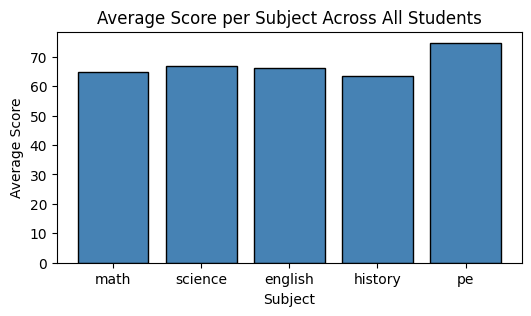

In [11]:
# 1.Bar Chart
import matplotlib.pyplot as plt

subject_cols = ['math', 'science', 'english', 'history', 'pe']

subject_means = df[subject_cols].mean()

plt.figure(figsize=(6, 3))
plt.bar(subject_means.index, subject_means.values, color='steelblue', edgecolor='black')

plt.title('Average Score per Subject Across All Students')
plt.xlabel('Subject')
plt.ylabel('Average Score')

plt.savefig('plot1_bar.png', dpi=150, bbox_inches='tight')
plt.show()

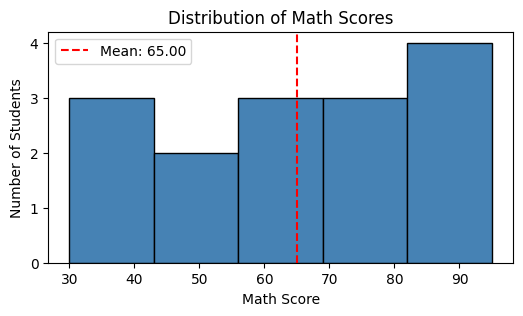

In [12]:
# 2.Histogram
plt.figure(figsize=(6, 3))
plt.hist(df['math'], bins=5, color='steelblue', edgecolor='black')

mean_math = df['math'].mean()
plt.axvline(mean_math, color='red', linestyle='--', label=f'Mean: {mean_math:.2f}')

plt.title('Distribution of Math Scores')
plt.xlabel('Math Score')
plt.ylabel('Number of Students')
plt.legend()

plt.savefig('plot2_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

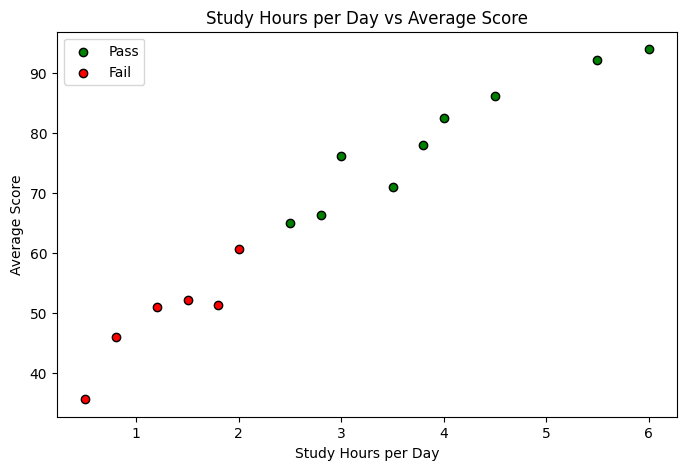

In [13]:
# 3.scatter plot
plt.figure(figsize=(8, 5))

pass_df = df[df['passed'] == 1]
fail_df = df[df['passed'] == 0]

plt.scatter(pass_df['study_hours_per_day'], pass_df['avg_score'], color='green', label='Pass', edgecolor='black')
plt.scatter(fail_df['study_hours_per_day'], fail_df['avg_score'], color='red', label='Fail', edgecolor='black')

plt.title('Study Hours per Day vs Average Score')
plt.xlabel('Study Hours per Day')
plt.ylabel('Average Score')
plt.legend()

plt.savefig('plot3_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

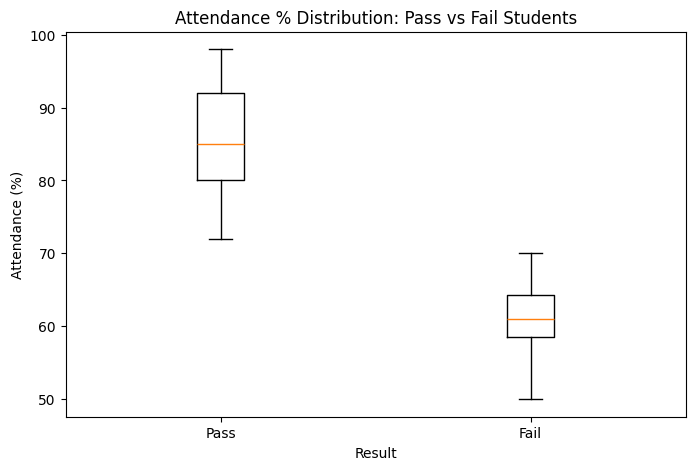

In [14]:
# 4.Box plot
plt.figure(figsize=(8, 5))

pass_attendance = df[df['passed'] == 1]['attendance_pct'].tolist()
fail_attendance = df[df['passed'] == 0]['attendance_pct'].tolist()

plt.boxplot([pass_attendance, fail_attendance], tick_labels=['Pass', 'Fail'])

plt.title('Attendance % Distribution: Pass vs Fail Students')
plt.xlabel('Result')
plt.ylabel('Attendance (%)')

plt.savefig('plot4_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

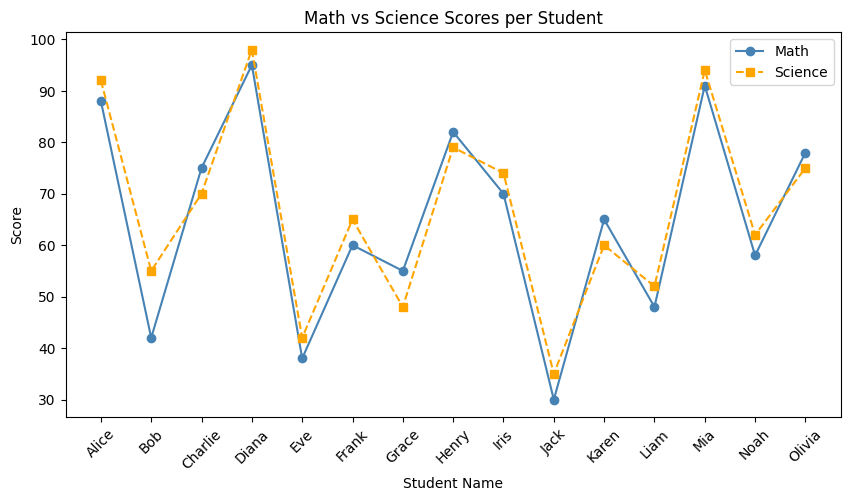

In [15]:
# 5.Line plot
plt.figure(figsize=(10, 5))

plt.plot(df['name'], df['math'], marker='o', linestyle='-', color='steelblue', label='Math')
plt.plot(df['name'], df['science'], marker='s', linestyle='--', color='orange', label='Science')

plt.title('Math vs Science Scores per Student')
plt.xlabel('Student Name')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend()

plt.savefig('plot5_line.png', dpi=150, bbox_inches='tight')
plt.show()

# Task 3 Data Visualization with Seaborn

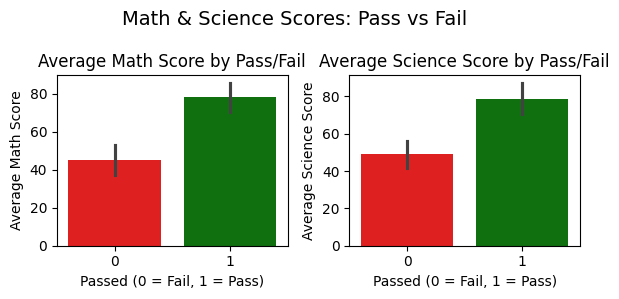

In [16]:
# Seaborn bar plot
import seaborn as sns

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 3))

sns.barplot(data=df, x='passed', y='math', hue='passed', legend=False, ax=ax1, palette=['red', 'green'])
ax1.set_title('Average Math Score by Pass/Fail')
ax1.set_xlabel('Passed (0 = Fail, 1 = Pass)')
ax1.set_ylabel('Average Math Score')

sns.barplot(data=df, x='passed', y='science', hue='passed', legend=False, ax=ax2, palette=['red', 'green'])
ax2.set_title('Average Science Score by Pass/Fail')
ax2.set_xlabel('Passed (0 = Fail, 1 = Pass)')
ax2.set_ylabel('Average Science Score')

plt.suptitle('Math & Science Scores: Pass vs Fail', fontsize=14)
plt.tight_layout()

plt.savefig('plot6_seaborn_bar.png', dpi=150, bbox_inches='tight')
plt.show()

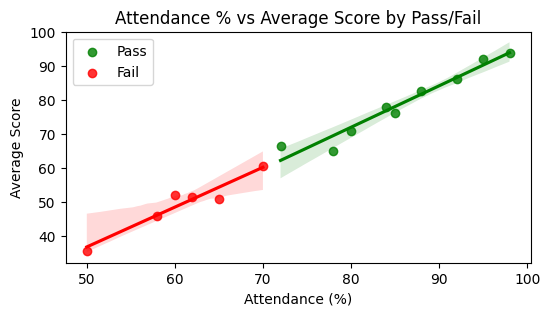

In [17]:
# Seaborn scatter plot
import matplotlib.pyplot as plt
import seaborn as sns
fig, ax = plt.subplots(figsize=(6, 3))

sns.regplot(data=df[df['passed'] == 1], x='attendance_pct', y='avg_score',
            ax=ax, color='green', label='Pass')

sns.regplot(data=df[df['passed'] == 0], x='attendance_pct', y='avg_score',
            ax=ax, color='red', label='Fail')

ax.set_title('Attendance % vs Average Score by Pass/Fail')
ax.set_xlabel('Attendance (%)')
ax.set_ylabel('Average Score')
ax.legend()

plt.savefig('plot7_seaborn_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# Seaborn vs Matplotlib Comparison:
# Seaborn is easier to use for statistical plots like bar and scatter plots
# because it directly accepts a DataFrame and handles grouping and colors automatically.
# Matplotlib gives more manual control but requires more lines of code
# for the same result, such as splitting groups and setting colors separately.

# Task 4 — Machine Learning with scikit-learn

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Step 1 - Separate features and target
feature_cols = ['math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day']
X = df[feature_cols]
y = df['passed']

# Step 2 - Split into train (80%) and test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

# Step 3 - Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("\nScaling done!")
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

Training samples: 12
Testing samples: 3

Scaling done!
X_train_scaled shape: (12, 7)
X_test_scaled shape: (3, 7)


In [ ]:
# Step 2 — Train a Model
from sklearn.linear_model import LogisticRegression

# Step 1 - Train the model
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

# Step 2 - Print training accuracy
train_accuracy = model.score(X_train_scaled, y_train)
print(f"Training Accuracy: {train_accuracy * 100:.2f}%")

Training Accuracy: 100.00%


In [21]:
# Evaluate the Model
# Step 1 - Predict on test set
y_pred = model.predict(X_test_scaled)

# Step 2 - Print test accuracy
test_accuracy = model.score(X_test_scaled, y_test)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

# Step 3 - Print each student with actual, predicted and correct/wrong
print("\nDetailed Predictions:")
print("-" * 45)

names = df.loc[X_test.index, 'name']

for name, actual, predicted in zip(names, y_test, y_pred):
    status = "✅ Correct" if actual == predicted else "❌ Wrong"
    print(f"{name:<10} | Actual: {actual} | Predicted: {predicted} | {status}")

Test Accuracy: 100.00%

Detailed Predictions:
---------------------------------------------
Jack       | Actual: 0 | Predicted: 0 | ✅ Correct
Liam       | Actual: 0 | Predicted: 0 | ✅ Correct
Alice      | Actual: 1 | Predicted: 1 | ✅ Correct


Feature Coefficients (sorted by importance):
---------------------------------------------
english                   | 0.8125
attendance_pct            | 0.5219
study_hours_per_day       | 0.4844
pe                        | 0.4750
math                      | 0.4379
science                   | 0.3230
history                   | 0.2629


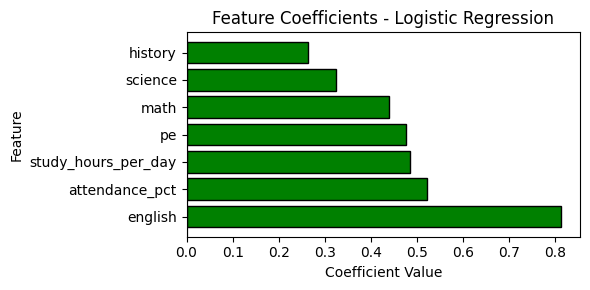

In [23]:
# Step 4 — Feature Importance
import matplotlib.pyplot as plt

# Step 1 - Extract coefficients
coefficients = model.coef_[0]

# Step 2 - Pair with feature names and sort by absolute value
coef_pairs = list(zip(feature_cols, coefficients))
coef_pairs_sorted = sorted(coef_pairs, key=lambda x: abs(x[1]), reverse=True)

print("Feature Coefficients (sorted by importance):")
print("-" * 45)
for feature, coef in coef_pairs_sorted:
    print(f"{feature:<25} | {coef:.4f}")

# Step 3 - Horizontal bar chart
features = [pair[0] for pair in coef_pairs_sorted]
coefs    = [pair[1] for pair in coef_pairs_sorted]
colors   = ['green' if c > 0 else 'red' for c in coefs]

plt.figure(figsize=(6, 3))
plt.barh(features, coefs, color=colors, edgecolor='black')

plt.title('Feature Coefficients - Logistic Regression')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig('plot8_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
# Step 5 — Predict for a New Student
# New student data - as DataFrame to avoid warning
new_student = pd.DataFrame([[75, 70, 68, 65, 80, 82, 3.2]], columns=feature_cols)

# Scale using same scaler
new_student_scaled = scaler.transform(new_student)

# Predict Pass or Fail
prediction = model.predict(new_student_scaled)
result = "Pass ✅" if prediction[0] == 1 else "Fail ❌"
print(f"Prediction: {result}")

# Predict probability
proba = model.predict_proba(new_student_scaled)
print(f"Probability of Fail: {proba[0][0] * 100:.2f}%")
print(f"Probability of Pass: {proba[0][1] * 100:.2f}%")

Prediction: Pass ✅
Probability of Fail: 9.20%
Probability of Pass: 90.80%
